# **K-Means Clustering - Unsupervised Learning**

---

<br>

## What is K-Means Clustering?
K-Means is an **unsupervised learning** algorithm used to group similar data points into **K** clusters. It finds the center (centroid) of each cluster and assigns points to the nearest one.

<br>

---

<br>

## How K-Means Works:
1. Choose **K** random centers (centroids).
2. Assign each data point to the closest centroid.
3. Update centroids based on the assigned points.
4. Repeat until centroids don’t change.

<br>

---

<br>

## Techniques:
- Elbow Method: Look for the "elbow" point in the WCSS plot.
- Silhouette Score: Measures the quality of clustering.
- Knee Method: Find the sharp bend in the WCSS curve to choose K.

<br>

---

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
X, y = make_blobs(n_samples = 1000, centers = 3, n_features = 2, random_state= 23)

In [3]:
X.shape

(1000, 2)

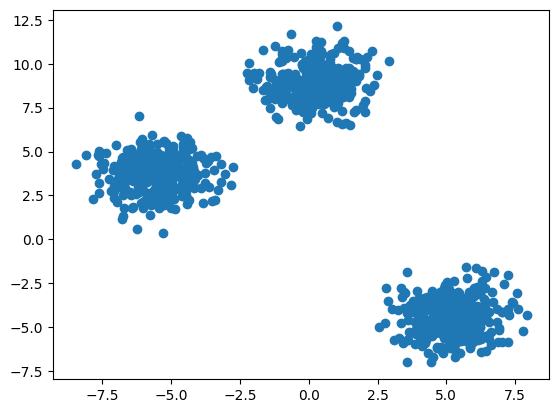

In [4]:
plt.scatter(X[:,0], X[:,1])

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=32)

In [6]:
from sklearn.cluster import KMeans

We are finding K value using Elbow Method and WCSS



In [7]:
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters = k, init = 'k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)

In [8]:
wcss

[33603.19972463431,
 8304.052252494153,
 1314.8045984506484,
 1170.8132361826238,
 1070.8767838105266,
 923.2615609019623,
 776.6414247485178,
 653.6806542551282,
 629.2890102047947,
 524.2943866322511]

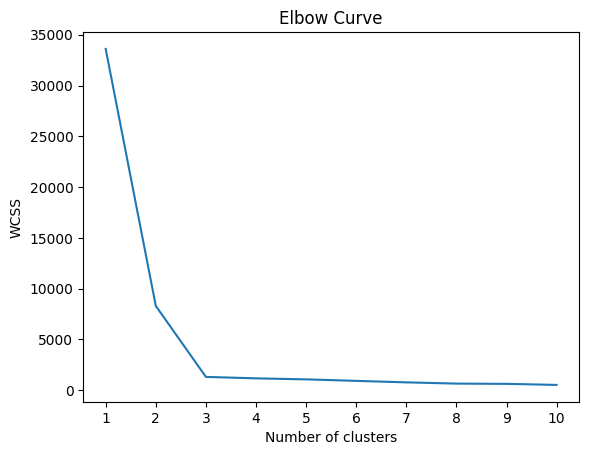

In [9]:
# Plot elbow curve
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.title('Elbow Curve')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

So we can see 3 is the best k value

In [10]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++')

In [11]:
y_labels = kmeans.fit_predict(X_train)

In [12]:
y_test_labels = kmeans.predict(X_test)

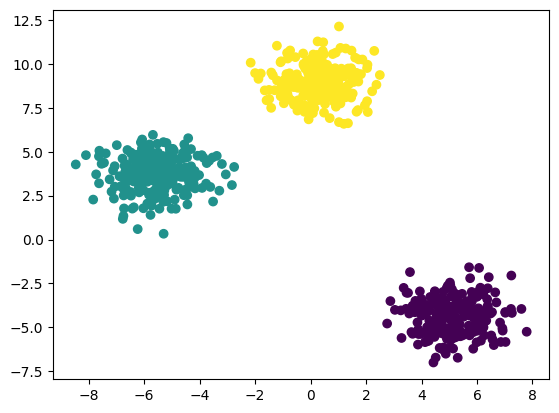

In [13]:
# Train Data Plots
plt.scatter(X_train[:,0], X_train[:,1], c=y_labels)

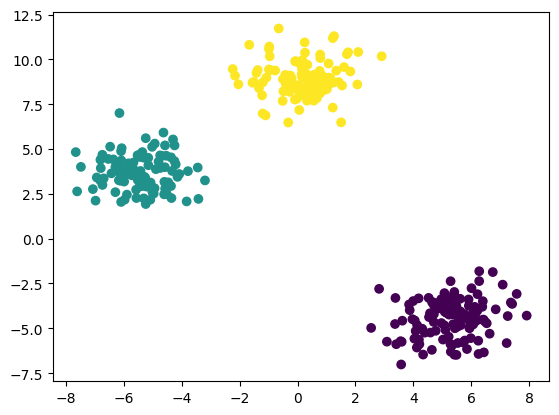

In [14]:
# Test Data Plots
plt.scatter(X_test[:,0], X_test[:,1], c=y_test_labels)

Technique we have used till now is manual. If the dataset is small then we can use this manual technique.
# Now we will see Automated Technique
It is very good technique for large dataset

In [15]:
## Knee Locator - It is used to find k value automatically
!pip install kneed

In [16]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
kl.elbow

3

**Performance Metrix : Silhouette Score**

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
silhouette_coefficients=[]
for k in range(2,11):
  kmeans = KMeans(n_clusters = k, init = 'k-means++')
  kmeans.fit(X_train)
  score = silhouette_score(X_train, kmeans.labels_)
  silhouette_coefficients.append(score)

In [19]:
silhouette_coefficients

[0.7184725904682323,
 0.8043330734620898,
 0.6347366459435266,
 0.475774652087123,
 0.4999228281100549,
 0.3193225413584909,
 0.3303606505430378,
 0.3283350223723743,
 0.3448270148086174]

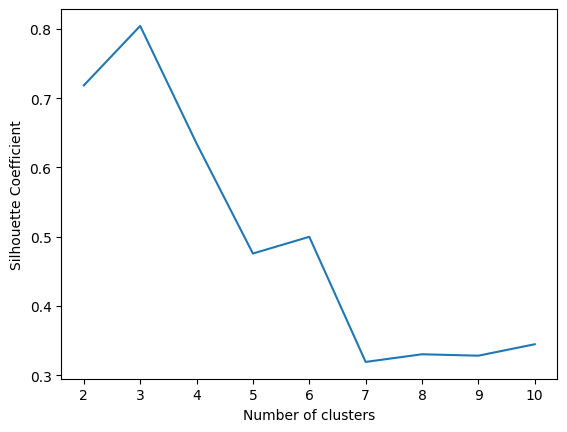

In [20]:
## Ploting Silhouette Score
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

# **So, You can see `3` has highest Accuracy which is around 80%**